In [ ]:
# uv add ipykernel numpy matplotlib pillow spiceypy poliastro astropy

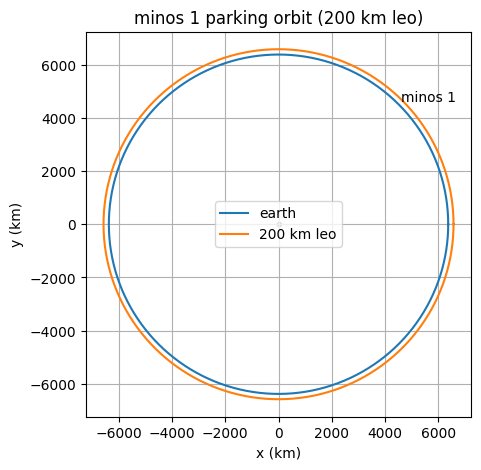

In [13]:
import numpy as np
import matplotlib.pyplot as plt

r_earth_km = 6378.0
h_leo_km = 200.0
r_leo_km = r_earth_km + h_leo_km

theta = np.linspace(0, 2*np.pi, 800)

plt.figure(figsize=(5,5))
plt.plot(r_earth_km*np.cos(theta), r_earth_km*np.sin(theta), label="earth")
plt.plot(r_leo_km*np.cos(theta), r_leo_km*np.sin(theta), label="200 km leo")

plt.scatter([0],[0], s=10)
plt.text(r_leo_km*0.7, r_leo_km*0.7, "minos 1", fontsize=10)

plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("x (km)")
plt.ylabel("y (km)")
plt.title("minos 1 parking orbit (200 km leo)")
plt.grid(True)
plt.legend()
plt.show()

saved: minos1_geometry_plus_phase_2030_2040.gif


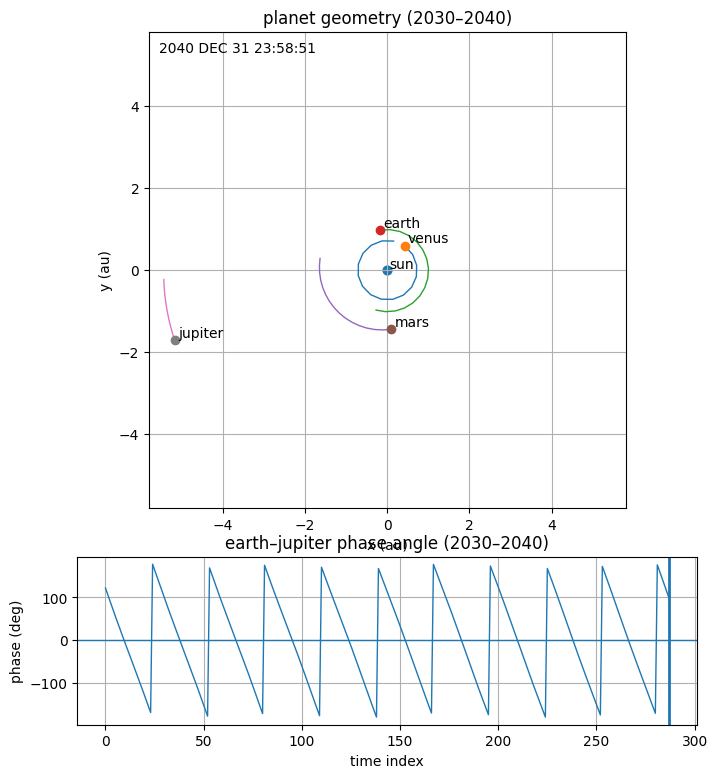

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from pathlib import Path
import spiceypy as sp

# ---------- kernels ----------
kern_dir = Path("../kernels")
sp.furnsh(str(kern_dir / "naif0012.tls"))
sp.furnsh(str(kern_dir / "de440s.bsp"))

AU_KM = 149597870.7

# ---------- time grid ----------
t0 = sp.str2et("2030-01-01 TDB")
t1 = sp.str2et("2040-12-31 TDB")
step_days = 14
times = np.arange(t0, t1 + step_days * 86400.0, step_days * 86400.0)

# ---------- helpers ----------
def pos_au(target, et):
    r, _ = sp.spkpos(target, et, "ECLIPJ2000", "NONE", "SUN")
    return np.array(r[:2]) / AU_KM  # x,y in AU

def angle_deg(target, et):
    xy = pos_au(target, et)
    return np.degrees(np.arctan2(xy[1], xy[0]))

def wrap180(x):
    return (x + 180.0) % 360.0 - 180.0

# ---------- bodies ----------
bodies = [
    ("VENUS BARYCENTER", "venus"),
    ("EARTH BARYCENTER", "earth"),
    ("MARS BARYCENTER", "mars"),
    ("JUPITER BARYCENTER", "jupiter"),
]

# precompute trajectories
traj = {name: np.vstack([pos_au(spice, et) for et in times]) for spice, name in bodies}

# precompute phase series (jupiter relative to earth)
phi = np.array([wrap180(angle_deg("JUPITER BARYCENTER", et) - angle_deg("EARTH BARYCENTER", et)) for et in times])
x_idx = np.arange(len(times))

# ---------- figure ----------
fig = plt.figure(figsize=(8, 9))
gs = fig.add_gridspec(2, 1, height_ratios=[3.4, 1.2], hspace=0.15)
ax_top = fig.add_subplot(gs[0, 0])
ax_bot = fig.add_subplot(gs[1, 0])

# top: geometry
ax_top.set_xlim(-5.8, 5.8)
ax_top.set_ylim(-5.8, 5.8)
ax_top.set_aspect("equal", adjustable="box")
ax_top.grid(True)
ax_top.set_xlabel("x (au)")
ax_top.set_ylabel("y (au)")
ax_top.set_title("planet geometry (2030–2040)")
ax_top.scatter([0], [0], s=40)
ax_top.text(0.05, 0.05, "sun", fontsize=10)
time_text = ax_top.text(0.02, 0.98, "", transform=ax_top.transAxes, va="top", fontsize=10)

trail_len = 15  # frames of trail

lines = {}
pts = {}
labels = {}
for _, name in bodies:
    (ln,) = ax_top.plot([], [], linewidth=1)
    (pt,) = ax_top.plot([], [], marker="o", markersize=6, linestyle="None")
    lines[name] = ln
    pts[name] = pt
    labels[name] = ax_top.text(0, 0, "", fontsize=10)

# bottom: phase angle
ax_bot.plot(x_idx, phi, linewidth=1)
ax_bot.axhline(0, linewidth=1)
ax_bot.grid(True)
ax_bot.set_xlabel("time index")
ax_bot.set_ylabel("phase (deg)")
ax_bot.set_title("earth–jupiter phase angle (2030–2040)")

vline = ax_bot.axvline(0, linewidth=2)

def init():
    for name in lines:
        lines[name].set_data([], [])
        pts[name].set_data([], [])
        labels[name].set_text("")
    time_text.set_text("")
    vline.set_xdata([0, 0])
    return list(lines.values()) + list(pts.values()) + list(labels.values()) + [time_text, vline]

def update(i):
    et = times[i]
    cal = sp.et2utc(et, "C", 0)
    time_text.set_text(cal)

    j0 = max(0, i - trail_len)
    for _, name in bodies:
        xy = traj[name]
        lines[name].set_data(xy[j0:i+1, 0], xy[j0:i+1, 1])
        pts[name].set_data([xy[i, 0]], [xy[i, 1]])
        labels[name].set_position((xy[i, 0] + 0.08, xy[i, 1] + 0.08))
        labels[name].set_text(name)

    vline.set_xdata([i, i])
    return list(lines.values()) + list(pts.values()) + list(labels.values()) + [time_text, vline]

anim = FuncAnimation(fig, update, frames=len(times), init_func=init, blit=True)

out_gif = "minos1_geometry_plus_phase_2030_2040.gif"
anim.save(out_gif, writer=PillowWriter(fps=12))
print("saved:", out_gif)

sp.kclear()

In [20]:
# cell 1 (compute only): spice + lambert grid, save arrays for plotting

import numpy as np
import spiceypy as sp
from pathlib import Path
from datetime import datetime, timedelta

from astropy import units as u
from poliastro.iod import izzo

sp.kclear()

kern_dir = Path("../kernels")
sp.furnsh(str(kern_dir / "naif0012.tls"))
sp.furnsh(str(kern_dir / "de440.bsp"))

mu_sun = 1.32712440018e11 * (u.km**3 / u.s**2)

EARTH_NAME = "EARTH BARYCENTER"
JUPITER_NAME = "JUPITER BARYCENTER"

def state_helio(body, et_val):
    st, _ = sp.spkezr(body, et_val, "ECLIPJ2000", "NONE", "SUN")
    r = np.array(st[:3]) * u.km
    v = np.array(st[3:]) * (u.km / u.s)
    return r, v

def date_grid(start, end, step_days):
    d = start
    out = []
    while d <= end:
        out.append(d)
        d += timedelta(days=step_days)
    return out

# replace your lambert_pairs and best_lambert_min_c3 functions with these

def lambert_pairs(mu, r1, r2, tof_sec, prograde=True):
    """Get all lambert solutions, filtering for prograde manually."""
    results = []
    
    # Try M=0 (single revolution) — most relevant for interplanetary
    for M in [0, 1, 2]:
        try:
            raw = izzo.lambert(mu, r1, r2, tof_sec * u.s,
                               prograde=prograde, M=M)
            v1, v2 = raw[0], raw[1]
            
            # Manually verify prograde: v1 should have positive component
            # along the cross product of r1 and r2 (angular momentum direction)
            r1_val = r1.to_value(u.km)
            v1_val = v1.to_value(u.km / u.s)
            r2_val = r2.to_value(u.km)
            
            h = np.cross(r1_val, r2_val)   # orbit normal direction
            if prograde and np.dot(h, np.cross(r1_val, v1_val)) < 0:
                # wrong direction — skip
                continue
            
            results.append((v1, v2))
        except Exception:
            break   # M too high, stop
    
    return results


def best_lambert_min_c3(mu, r1, v1_body, r2, v2_body, tof_sec, prograde=True):
    pairs = lambert_pairs(mu, r1, r2, tof_sec, prograde=prograde)
    best = None
    for v1_sc, v2_sc in pairs:
        vinf_E = np.linalg.norm((v1_sc - v1_body).to_value(u.km / u.s))
        C3 = vinf_E**2
        if best is None or C3 < best["C3"]:
            vinf_J = np.linalg.norm((v2_sc - v2_body).to_value(u.km / u.s))
            best = dict(C3=C3, vinfJ=vinf_J)
    return best

# sanity check
et_test = sp.str2et("2031 AUG 24 00:01:09.182")
_ = state_helio(EARTH_NAME, et_test)
_ = state_helio(JUPITER_NAME, et_test)
print("ok: spice states exist for barycenters")

# -----------------------
# FIXED: TOF range now starts at 400 days to catch the actual
# optimal windows. Hohmann TOF is ~998 days so we bracket it
# well on both sides. Upper bound reduced to 1500 — beyond that
# you're deep into poor solutions and it just slows things down.
# -----------------------
step_days = 10
launch_dates = date_grid(datetime(2030, 1, 1), datetime(2040, 12, 31), step_days)

tof_days = np.arange(400, 1501, 10)   # 400–1500 days, finer step
tof_sec  = tof_days.astype(float) * 86400.0
tof_yrs  = tof_days / 365.25

nl = len(launch_dates)
nt = len(tof_days)

print(f"grid: {nl} launch dates × {nt} TOF steps = {nl*nt:,} points")

C3_LT    = np.full((nt, nl), np.nan)
vinfJ_LT = np.full((nt, nl), np.nan)

lambert_ok   = 0
lambert_fail = 0
first_err    = None

for j, ld in enumerate(launch_dates):
    etL = sp.datetime2et(ld)
    rE, vE = state_helio(EARTH_NAME, etL)

    for i, ts in enumerate(tof_sec):
        ad  = ld + timedelta(seconds=float(ts))
        etA = sp.datetime2et(ad)
        rJ, vJ = state_helio(JUPITER_NAME, etA)

        try:
            best = best_lambert_min_c3(mu_sun, rE, vE, rJ, vJ, ts, prograde=True)
        except Exception as e:
            lambert_fail += 1
            if first_err is None:
                first_err = e
            continue

        if best is None:
            lambert_fail += 1
            continue

        lambert_ok += 1
        C3_LT[i, j]    = best["C3"]
        vinfJ_LT[i, j] = best["vinfJ"]

finite = np.isfinite(C3_LT).sum()
print("lambert ok:", lambert_ok, "  lambert fail:", lambert_fail)
print("finite C3:", finite, "/", C3_LT.size)
if first_err is not None:
    print("first lambert error:", repr(first_err))

if finite == 0:
    raise RuntimeError("0 feasible points.")

# quick sanity on minimum C3 — should be in the 60-120 km²/s² range
min_c3 = np.nanmin(C3_LT)
print(f"\nminimum C3 in grid: {min_c3:.1f} km²/s²  (expect ~60–120 for direct E→J)")
print(f"corresponding v_inf: {np.sqrt(min_c3):.2f} km/s")

# also update tof_yrs for plotting cell

ok: spice states exist for barycenters
grid: 402 launch dates × 111 TOF steps = 44,622 points
lambert ok: 22241   lambert fail: 22381
finite C3: 22241 / 44622

minimum C3 in grid: 76.7 km²/s²  (expect ~60–120 for direct E→J)
corresponding v_inf: 8.76 km/s


c3 kept (best 30%): 4459 / 28416   cap: 244.99346904873406


/var/folders/dh/7_xd8v2j4yl57yh02f1161740000gn/T/ipykernel_2232/4177189225.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('YlOrRd')


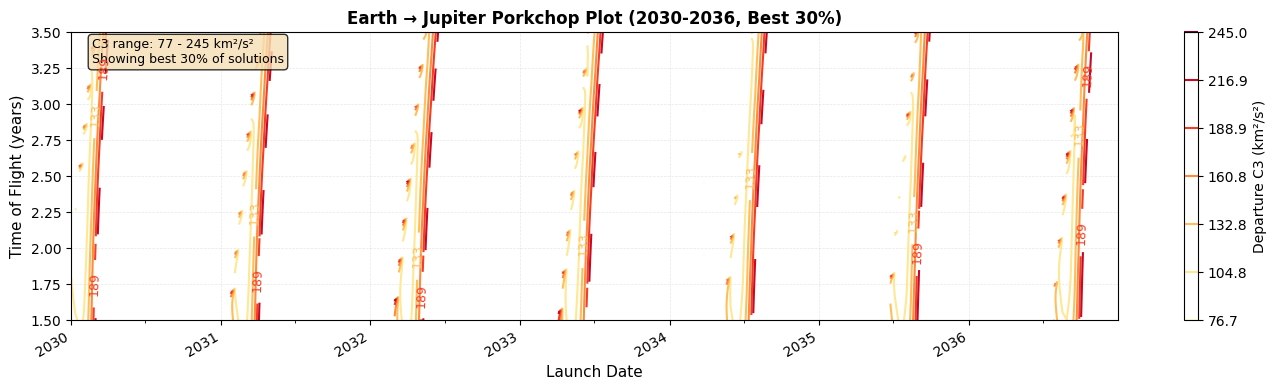

In [23]:
# cell 2 (plot only): properly proportioned porkchop with 2030-2036 focus
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import cm
from datetime import datetime

# -----------------------
# Filter to 2030-2036 launch window (STRICT)
# -----------------------
L_full = mdates.date2num(launch_dates)
T_full = tof_yrs

# Strict date filtering
start_date = mdates.date2num(datetime(2030, 1, 1))
end_date = mdates.date2num(datetime(2036, 12, 31))
date_mask = (L_full >= start_date) & (L_full <= end_date)
date_indices = np.where(date_mask)[0]

# Slice the data
L = L_full[date_indices]
C3_filtered = C3_LT[:, date_indices]

T = tof_yrs
X, Y = np.meshgrid(L, T)

# -----------------------
# filter: keep only "good" region
# -----------------------
C3 = np.array(C3_filtered, copy=True)
C3[~np.isfinite(C3)] = np.nan

finite0 = C3[np.isfinite(C3)]
if finite0.size == 0:
    raise RuntimeError("no finite C3 values to plot")

keep_pct = 30
max_c3 = np.percentile(finite0, keep_pct)
C3[C3 > max_c3] = np.nan

finite = C3[np.isfinite(C3)]
print(f"c3 kept (best {keep_pct}%):", finite.size, "/", C3.size, "  cap:", max_c3)

if finite.size == 0:
    raise RuntimeError("filter too aggressive. increase keep_pct")

C3m = np.ma.array(C3, mask=~np.isfinite(C3))

# -----------------------
# Fewer contour levels - just essentials
# -----------------------
min_c3 = np.nanmin(finite)
# Just 6-7 levels: min, max, and a few in between
levels = np.linspace(min_c3, max_c3, 7)

# -----------------------
# Plot with MUCH BETTER ASPECT RATIO (squished vertical)
# -----------------------
fig, ax = plt.subplots(figsize=(14, 4))  # Even shorter!

cmap = cm.get_cmap('YlOrRd')

# Plot colored contour lines
cs = ax.contour(X, Y, C3m, levels=levels, cmap=cmap, linewidths=1.5)

# Add colorbar
cbar = plt.colorbar(cs, ax=ax, label='Departure C3 (km²/s²)')

# Label most contours since we only have a few
label_levels = levels[::2]  # Every other one
ax.clabel(cs, levels=label_levels, fmt=lambda v: f"{v:.0f}", inline=True, fontsize=9)

ax.set_xlabel("Launch Date", fontsize=11)
ax.set_ylabel("Time of Flight (years)", fontsize=11)
ax.set_title(f"Earth → Jupiter Porkchop Plot (2030-2036, Best {keep_pct}%)", 
             fontsize=12, fontweight='bold')

# Better date formatting with STRICT limits
ax.set_xlim([start_date, end_date])  # Hard limit on x-axis
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator((1, 7)))
fig.autofmt_xdate()

# Tighter Y-axis limits to match new TOF range (400-1500 days = 1.1-4.1 years)
ax.set_ylim([1.5, 3.5])

# Grid for readability
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# Info box
textstr = f'C3 range: {min_c3:.0f} - {max_c3:.0f} km²/s²\n'
textstr += f'Showing best {keep_pct}% of solutions'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

In [22]:
# cell 3 (analysis): extract key numerical values from porkchop plot

import numpy as np
from datetime import datetime, timedelta

C3 = np.array(C3_LT, copy=True)
C3[~np.isfinite(C3)] = np.nan

# Filter to 2030-2036
start_date_dt = datetime(2030, 1, 1)
end_date_dt   = datetime(2036, 12, 31)
date_mask     = [(d >= start_date_dt and d <= end_date_dt) for d in launch_dates]
date_indices  = np.where(date_mask)[0]

C3_window    = C3[:, date_indices]
dates_window = [launch_dates[i] for i in date_indices]

# Find absolute minimum C3
min_idx     = np.unravel_index(np.nanargmin(C3_window), C3_window.shape)
min_c3      = C3_window[min_idx]
min_tof_days = tof_days[min_idx[0]]
min_launch  = dates_window[min_idx[1]]
min_arrival = min_launch + timedelta(days=int(min_tof_days))

r_leo    = 6378 + 200
mu_earth = 398600.4418
v_circular  = np.sqrt(mu_earth / r_leo)
v_escape    = np.sqrt(2) * v_circular
v_inf_min   = np.sqrt(min_c3)
v_hyp_min   = np.sqrt(v_escape**2 + v_inf_min**2)
delta_v_min = v_hyp_min - v_circular

print("=" * 70)
print("EUROPA LANDER MISSION - PORKCHOP ANALYSIS (2030-2036)")
print("=" * 70)
print()
print("ABSOLUTE MINIMUM C3 TRAJECTORY:")
print(f"  Launch Date:      {min_launch.strftime('%Y-%m-%d')}")
print(f"  Arrival Date:     {min_arrival.strftime('%Y-%m-%d')}")
print(f"  Time of Flight:   {min_tof_days:.0f} days ({min_tof_days/365.25:.2f} years)")
print(f"  Departure C3:     {min_c3:.1f} km²/s²")
print(f"  Departure V∞:     {v_inf_min:.2f} km/s")
print(f"  Required ΔV from LEO (200 km): {delta_v_min:.3f} km/s")
print()

# -----------------------
# Updated threshold — with the fixed TOF range you should now
# see C3 values in the 60-120 range. Set threshold accordingly.
# Adjust downward if still too many results, upward if too few.
# -----------------------
reasonable_c3 = 80.0

print("=" * 70)
print(f"LAUNCH OPPORTUNITIES WITH C3 < {reasonable_c3} km²/s²:")
print("=" * 70)
print()

opportunities = []
for j, ld in enumerate(dates_window):
    for i, td in enumerate(tof_days):
        c3_val = C3_window[i, j]
        if np.isfinite(c3_val) and c3_val < reasonable_c3:
            ad    = ld + timedelta(days=int(td))
            v_inf = np.sqrt(c3_val)
            v_hyp = np.sqrt(v_escape**2 + v_inf**2)
            dv    = v_hyp - v_circular
            opportunities.append({
                'launch'   : ld,
                'arrival'  : ad,
                'tof_days' : td,
                'c3'       : c3_val,
                'v_inf'    : v_inf,
                'delta_v'  : dv
            })

opportunities.sort(key=lambda x: x['c3'])

if len(opportunities) == 0:
    print(f"No opportunities found with C3 < {reasonable_c3} km²/s²")
    print(f"Minimum C3 in window: {np.nanmin(C3_window):.1f} km²/s²")
    print(f"Try increasing reasonable_c3 above that value.")
else:
    # Deduplicate: keep only the best C3 per ~30-day launch window
    # so we get one representative per synodic opportunity, not hundreds
    # of near-identical grid points
    deduped = []
    last_launch = None
    for opp in opportunities:
        if last_launch is None or (opp['launch'] - last_launch).days > 30:
            deduped.append(opp)
            last_launch = opp['launch']

    print(f"Found {len(deduped)} distinct launch window(s):")
    print()
    for idx, opp in enumerate(deduped[:6], 1):
        print(f"  #{idx}:")
        print(f"    Launch:       {opp['launch'].strftime('%Y-%m-%d')}")
        print(f"    Arrival:      {opp['arrival'].strftime('%Y-%m-%d')}")
        print(f"    TOF:          {opp['tof_days']:.0f} days ({opp['tof_days']/365.25:.2f} yr)")
        print(f"    C3:           {opp['c3']:.1f} km²/s²")
        print(f"    V∞:           {opp['v_inf']:.2f} km/s")
        print(f"    ΔV from LEO:  {opp['delta_v']:.3f} km/s")
        print()

print("=" * 70)
print("MISSION PARAMETERS:")
print("=" * 70)
print(f"  Spacecraft mass in LEO:  15,000 kg")
print(f"  LEO altitude:            200 km (circular)")
print(f"  LEO velocity:            {v_circular:.3f} km/s")
print(f"  Earth escape velocity:   {v_escape:.3f} km/s")
print()

print("=" * 70)
print("STATISTICS (2030-2036 WINDOW):")
print("=" * 70)
all_c3 = C3_window[np.isfinite(C3_window)]
print(f"  Total feasible trajectories:  {all_c3.size:,}")
print(f"  C3 range:                     {np.min(all_c3):.1f} - {np.max(all_c3):.1f} km²/s²")
print(f"  Median C3:                    {np.median(all_c3):.1f} km²/s²")
print(f"  C3 < 100 km²/s²:              {np.sum(all_c3 < 100):,} opportunities")
print(f"  C3 <  80 km²/s²:              {np.sum(all_c3 <  80):,} opportunities")
print(f"  C3 <  60 km²/s²:              {np.sum(all_c3 <  60):,} opportunities")

EUROPA LANDER MISSION - PORKCHOP ANALYSIS (2030-2036)

ABSOLUTE MINIMUM C3 TRAJECTORY:
  Launch Date:      2030-01-21
  Arrival Date:     2032-05-10
  Time of Flight:   840 days (2.30 years)
  Departure C3:     76.7 km²/s²
  Departure V∞:     8.76 km/s
  Required ΔV from LEO (200 km): 6.283 km/s

LAUNCH OPPORTUNITIES WITH C3 < 80.0 km²/s²:

Found 1 distinct launch window(s):

  #1:
    Launch:       2030-01-21
    Arrival:      2032-05-10
    TOF:          840 days (2.30 yr)
    C3:           76.7 km²/s²
    V∞:           8.76 km/s
    ΔV from LEO:  6.283 km/s

MISSION PARAMETERS:
  Spacecraft mass in LEO:  15,000 kg
  LEO altitude:            200 km (circular)
  LEO velocity:            7.784 km/s
  Earth escape velocity:   11.009 km/s

STATISTICS (2030-2036 WINDOW):
  Total feasible trajectories:  14,862
  C3 range:                     76.7 - 2503.3 km²/s²
  Median C3:                    562.9 km²/s²
  C3 < 100 km²/s²:              815 opportunities
  C3 <  80 km²/s²:              16